In [29]:
%load_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [30]:
%autoreload 2

In [28]:
import numpy as np
import scipy as sc
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import sys

import sympy

sys.path.append('//allen/aics/assay-dev/users/Erin/cell-state/git-repos/langevin-regression')
sys.path.append('//allen/aics/assay-dev/users/Erin/cell-state/git-repos/hcs-data-analysis/pycode')

# import SINDY for Langevin
import utils


# in pycode folder, includes all the langevin-regression code implemented for 2d
from langevin import *
import langevin_sindy as lgt # torch version of langevin regression
import torch

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Load MAE data

Masked autoencoder dataset info:
- columns 0-255 are the latent features of the contrastive model
- location gives a unique id for each 512x512 patch of the image (stitched FOVs) that is consistent across time (54 locations)
- time is the index into the movie (0 to 576, units 5 minutes)

Original endothelial cell dataset info (from `cellsmap/cellsmap/data_config.yaml`):
- flow rate of 20 dyn/cm^2 from 0 to 24 hours
- flow rate of 6 dyn/cm^2 from 24 to 48 hours
- time interval between images (data points) is 5 minutes

In [2]:
path_to_data = "//allen/aics/assay-dev/users/Benji/cellsmap/results/mae_with_crops/predictions.csv"
df = pd.read_csv(path_to_data)
df = df.sort_values(by=['time'])
df.head()

,0,1,2,3,4,5,6,7,8,9,...,248,249,250,251,252,253,254,255,time,crop_path
31157,-0.403339,-0.054357,0.081670,0.036840,-0.436207,-0.102985,0.076605,0.077822,-0.157741,-0.727846,...,0.497138,-0.208936,-0.558685,-0.234292,0.384501,-0.062226,0.024067,-0.421904,0,/allen/aics/assay-dev/users/Benji/cellsmap/res...
31127,-0.450235,-0.070796,0.105538,0.079780,-0.540502,0.018185,-0.036170,0.156937,-0.063172,-0.816669,...,0.481960,-0.301716,-0.597936,-0.252452,0.370932,-0.124557,0.026116,-0.305511,0,/allen/aics/assay-dev/users/Benji/cellsmap/res...
31126,-0.448404,-0.111460,0.142800,0.120814,-0.541331,-0.010855,-0.061189,0.149291,-0.000738,-0.803125,...,0.523833,-0.270956,-0.640790,-0.259127,0.390716,-0.089092,0.081470,-0.359990,0,/allen/aics/assay-dev/users/Benji/cellsmap/res...
31125,-0.426372,-0.069539,0.141867,0.091545,-0.488647,0.062850,-0.044467,0.045660,-0.004227,-0.799495,...,0.495170,-0.304079,-0.594390,-0.296582,0.343196,-0.006954,0.014301,-0.332998,0,/allen/aics/assay-dev/users/Benji/cellsmap/res...
31124,-0.417436,-0.076289,0.168689,0.086005,-0.551153,-0.020510,-0.016977,0.134473,0.026202,-0.807542,...,0.450496,-0.306771,-0.600442,-0.283535,0.304344,-0.081256,0.028350,-0.356603,0,/allen/aics/assay-dev/users/Benji/cellsmap/res...


In [3]:
crop_paths = df['crop_path'].values.tolist()
loc_idx = []
for path in crop_paths:
    loc_idx.append(int(path.split("_")[-1].split(".")[0]))

# add crop index to dataframe
df['loc_idx'] = loc_idx
df = df.sort_values(by=['loc_idx','time'])
df.head()

,0,1,2,3,4,5,6,7,8,9,...,249,250,251,252,253,254,255,time,crop_path,loc_idx
31104,-0.398590,-0.097292,0.172141,0.080109,-0.482702,0.052990,0.006016,0.044518,0.006743,-0.787663,...,-0.284757,-0.615395,-0.329621,0.360263,-0.080246,-0.045336,-0.240576,0,/allen/aics/assay-dev/users/Benji/cellsmap/res...,0
31050,-0.382089,-0.089444,0.177880,0.079264,-0.471801,0.063093,0.002037,0.044190,-0.000364,-0.799524,...,-0.306161,-0.621000,-0.331049,0.372629,-0.079632,-0.050508,-0.230928,1,/allen/aics/assay-dev/users/Benji/cellsmap/res...,0
30996,-0.392864,-0.096144,0.184194,0.079237,-0.452374,0.044341,-0.014766,0.041377,0.012348,-0.787491,...,-0.291067,-0.644912,-0.323674,0.375982,-0.079339,-0.040268,-0.237306,2,/allen/aics/assay-dev/users/Benji/cellsmap/res...,0
30942,-0.371442,-0.060800,0.233763,0.087936,-0.428809,0.027982,-0.022522,-0.002160,0.009486,-0.764404,...,-0.295151,-0.653149,-0.348773,0.372408,-0.087380,-0.037856,-0.218462,3,/allen/aics/assay-dev/users/Benji/cellsmap/res...,0
30888,-0.347594,-0.086194,0.240871,0.099872,-0.413871,0.030197,-0.016531,0.003822,0.029250,-0.750722,...,-0.281186,-0.692581,-0.374617,0.368207,-0.094991,-0.063941,-0.200051,4,/allen/aics/assay-dev/users/Benji/cellsmap/res...,0


In [4]:
X = df[df.columns[~df.columns.isin(['crop_path','loc_idx','time'])]].values # remove location and time columns, just get points in feature space
scaler = StandardScaler().fit(X)
X = (X-scaler.mean_)/scaler.scale_ 

In [5]:
data_scaled = np.hstack((X,df['time'].values[:,None],df['loc_idx'].values[:,None]))
df_scaled = pd.DataFrame(data_scaled,columns=df.columns[~df.columns.isin(['crop_path'])])
df_scaled['loc_idx'] = df_scaled['loc_idx'].astype(int)
df_scaled['time'] = df_scaled['time'].astype(int)
df_scaled.head()

,0,1,2,3,4,5,6,7,8,9,...,248,249,250,251,252,253,254,255,time,loc_idx
0,0.368907,-0.343259,0.714692,-0.304539,0.422639,0.770636,0.243554,-0.103302,0.807505,-0.386602,...,-0.940052,-0.549784,-0.374846,-0.751731,-0.232241,0.342965,-1.270132,0.146794,0,0
1,0.670700,-0.180026,0.752634,-0.323548,0.580131,0.926589,0.152696,-0.106876,0.743893,-0.559448,...,-1.034063,-1.019168,-0.426235,-0.772118,-0.080877,0.354546,-1.378975,0.239760,1,0
2,0.473646,-0.319387,0.794371,-0.324145,0.860797,0.637138,-0.230992,-0.137537,0.857665,-0.384094,...,-0.788507,-0.688157,-0.645464,-0.666849,-0.039828,0.360079,-1.163492,0.178301,2,0
3,0.865429,0.415725,1.122074,-0.128383,1.201240,0.384622,-0.408106,-0.612177,0.832052,-0.047665,...,-0.963045,-0.777717,-0.720983,-1.025108,-0.083578,0.208302,-1.112725,0.359881,3,0
4,1.301592,-0.112444,1.169064,0.140232,1.417048,0.418814,-0.271307,-0.546967,1.008938,0.151723,...,-1.201304,-0.471477,-1.082503,-1.393998,-0.135006,0.064656,-1.661661,0.537279,4,0


Number of modes to explain 95% of variance:  12


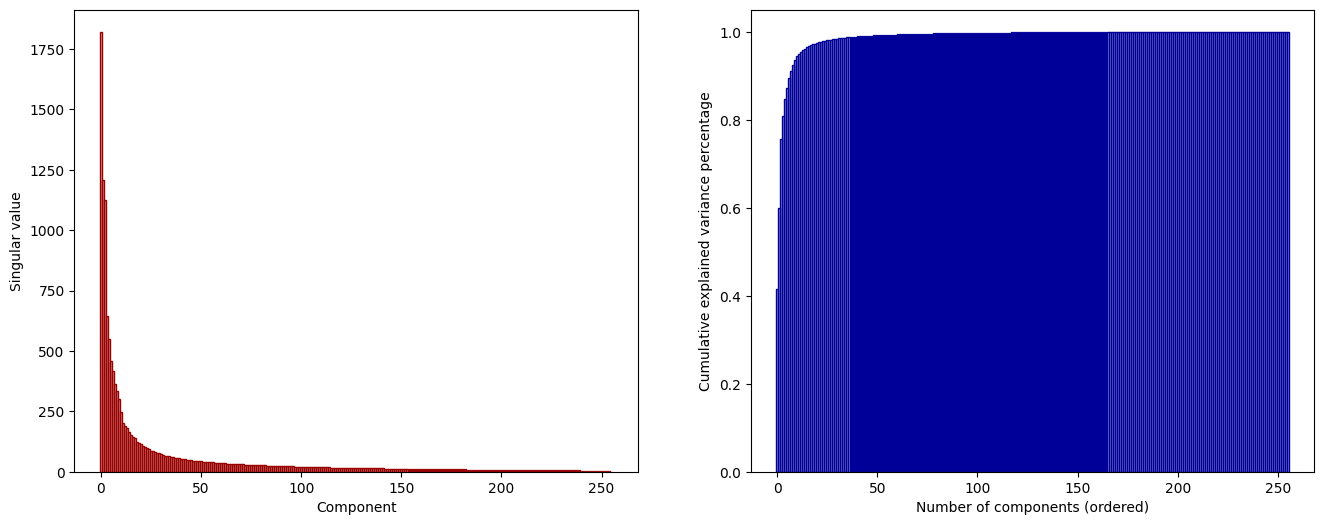

In [6]:
pcaFull = PCA().fit(X) # PCA on scaled contrastive learning features

fig, ax = plt.subplots(1,2, figsize=(16,6))

ax[0].bar(np.arange(X.shape[1]),pcaFull.singular_values_, color=(0.6,0,0.0,0.3),edgecolor=(0.6,0,0.0,1.0))
ax[0].set_xlabel("Component")
ax[0].set_ylabel("Singular value")

ax[1].bar(np.arange(X.shape[1]),np.cumsum(pcaFull.explained_variance_ratio_),color=(0.0,0,0.6,0.3),edgecolor=(0.0,0,0.6,1.0))
ax[1].set_xlabel("Number of components (ordered)")
ax[1].set_ylabel("Cumulative explained variance percentage")

num_modes_95 = np.where(np.cumsum(pcaFull.explained_variance_ratio_) > 0.95)[0].min()
print("Number of modes to explain 95% of variance: ", num_modes_95)

In [7]:
pcaFull.explained_variance_ratio_[1]

0.18265602513478565

Text(0, 0.5, 'Cumulative explained variance percentage')

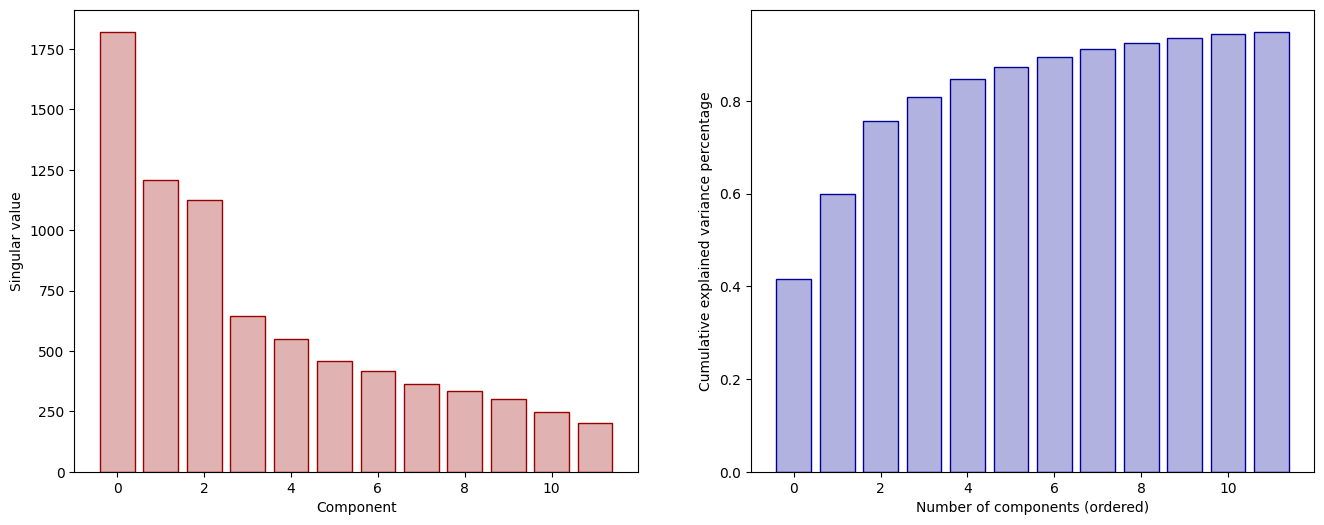

In [8]:
fig, ax = plt.subplots(1,2, figsize=(16,6))

ax[0].bar(np.arange(num_modes_95),pcaFull.singular_values_[:num_modes_95], color=(0.6,0,0.0,0.3),edgecolor=(0.6,0,0.0,1.0))
ax[0].set_xlabel("Component")
ax[0].set_ylabel("Singular value")

ax[1].bar(np.arange(num_modes_95),np.cumsum(pcaFull.explained_variance_ratio_)[:num_modes_95],color=(0.0,0,0.6,0.3),edgecolor=(0.0,0,0.6,1.0))
ax[1].set_xlabel("Number of components (ordered)")
ax[1].set_ylabel("Cumulative explained variance percentage")

In [9]:
pca2D = PCA(n_components=2).fit(X)
W_2D = pca2D.components_.T # in data matrix X, each column is a feature, each row is a data point: take transpose of projection matrix, right multiply
X_pca = X@W_2D # project data into 2D (each point is a row vector)

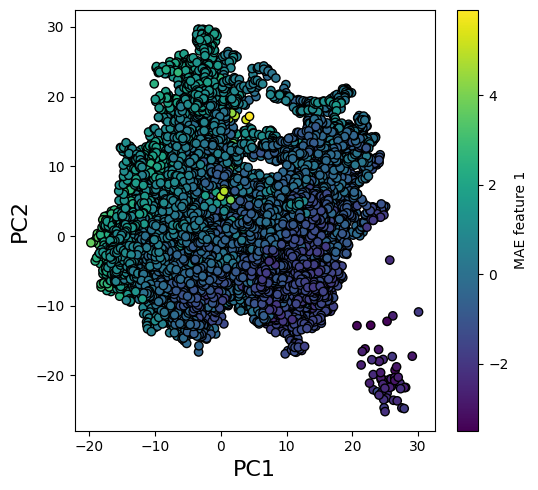

In [10]:
idx = 0 # color each point by value of contrastive learning feature idx
fig, ax = plt.subplots(1,1, figsize=(5.5,5))
sc_plt = ax.scatter(X_pca[:,0], X_pca[:,1],c=X[:,idx],edgecolor=(0.0,0.0,0.0,1.0)) 
plt.colorbar(sc_plt,label='MAE feature '+str(idx+1), ax=ax)
ax.set_xlabel("PC1", fontsize=16)
ax.set_ylabel("PC2", fontsize=16)
plt.tight_layout()

In [11]:
loc_traj = []
loc_traj_2D = []
loc_traj_PCA = []
pcaND = PCA(n_components=num_modes_95).fit(X) # PCA on scaled contrastive learning features, keep top modes for 95% of variance
W_ND = pcaND.components_.T # in data matrix X, each column is a feature, each row is a data point: take transpose of projection matrix, right multiply
for loc in df_scaled.loc_idx.unique():
    loc_df = df_scaled[df_scaled.loc_idx== loc]
    traj = loc_df[loc_df.columns[~loc_df.columns.isin(['loc_idx','time'])]].values # get scaled contrastive learning features over time for this location
    loc_traj.append(traj)
    loc_traj_2D.append(traj@W_2D) # project trajectory into 2D
    loc_traj_PCA.append(traj@W_ND) # project trajectory into top modes for 95% of variance

### Build time series arrays

In [12]:
X_t_full = np.array(loc_traj) # full trajectories for all locations, all times
num_loc = X_t_full.shape[0]
num_t = X_t_full.shape[1]
num_feats = X_t_full.shape[-1]
t_change = (24*60 - 25)//5 # time point at which to change from high to low flow occurs (25 minutes before 24 hours)

X_t = torch.from_numpy(np.array(loc_traj_PCA)) # full trajectories for all locations, all times (top PCA modes for 95% of variance)

X_t_high = X_t[:,:t_change,:] # high flow trajectories (i.e., features per location over all time)
X_t_low = X_t[:,t_change:,:] # low flow trajectories

dt = 5 # time interval between frames in minutes

Text(0, 0.5, 'PC1')

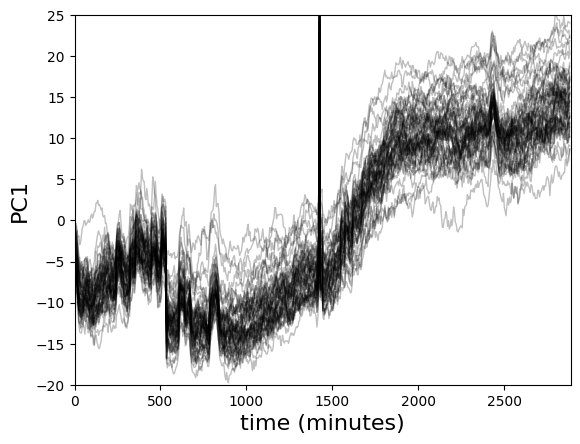

In [13]:
# plot top PCA mode vs time for each location
for i in range(num_loc):
    plt.plot(5*torch.arange(num_t),X_t[i,:,0],'k-',alpha=0.25,linewidth=1)
plt.xlim([0,(num_t)*5])
plt.ylim([-20,25])
plt.xlabel("time (minutes)", fontsize=16)
plt.ylabel("PC1", fontsize=16)

Text(0, 0.5, 'PC2')

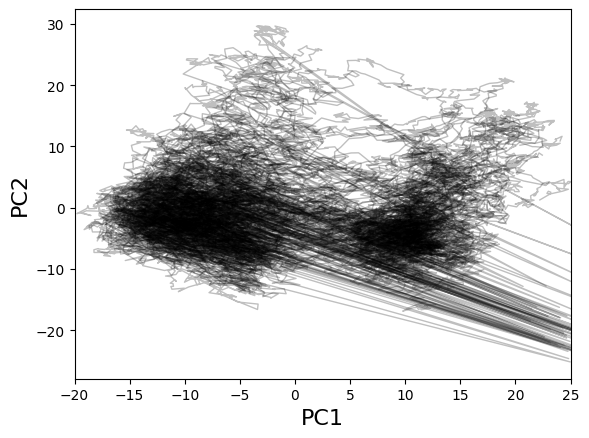

In [14]:
for i in range(num_loc):
    plt.plot(X_t[i,:,0],X_t[i,:,1],'k-',alpha=0.25,linewidth=1)
#plt.xlim([0,(num_t)*5])
plt.xlim([-20,25])
plt.xlabel("PC1", fontsize=16)
plt.ylabel("PC2", fontsize=16)

Text(0, 0.5, 'PC1')

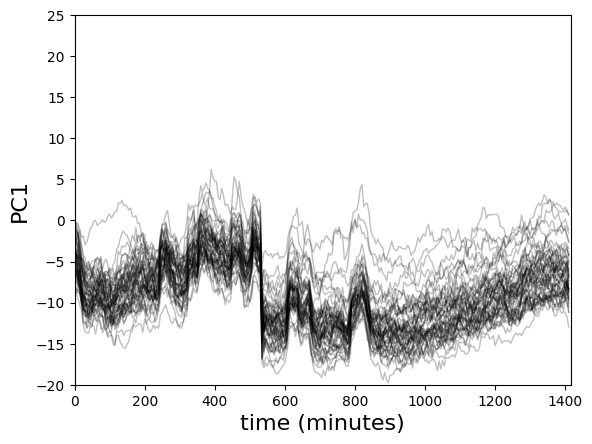

In [15]:
# plot top PCA mode vs time for each location at high flow
for i in range(num_loc):
    plt.plot(5*torch.arange(t_change),X_t_high[i,:,0],'k-',alpha=0.25,linewidth=1)
plt.xlim([0,(t_change)*5])
plt.ylim([-20,25])
plt.xlabel("time (minutes)", fontsize=16)
plt.ylabel("PC1", fontsize=16)

In [16]:
num_t-t_change

294

Text(0, 0.5, 'PC1')

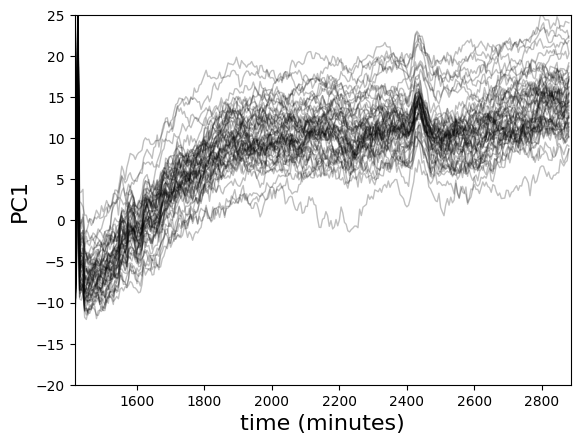

In [17]:
# plot top PCA mode vs time for each location at low flow
for i in range(num_loc):
    plt.plot(5*torch.arange(t_change,num_t),X_t_low[i,:,0],'k-',alpha=0.25,linewidth=1)
plt.xlim([5*t_change,5*num_t])
plt.ylim([-20,25])
plt.xlabel("time (minutes)", fontsize=16)
plt.ylabel("PC1", fontsize=16)

## Langevin regression (2D)

### High flow trajectories

In [18]:
# Plot truth, fast sampling, slow sampling

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728',
              '#9467bd', '#8c564b', '#e377c2', '#7f7f7f',
              '#bcbd22', '#17becf']

data = [X_t_high[i,:,:2].numpy() for i in range(num_loc)] # high flow data, pass as list into KM_avg
data_stationary = [X_t_high[i,100:,:2].numpy() for i in range(num_loc)] # for getting stationary distribution

N = 32
min0 = min([min(traj[:,0]) for traj in data])
max0 = max([max(traj[:,0]) for traj in data])
bin0_min = 0.5*(np.floor(min0)+np.round(min0,1))
bin0_max = 0.5*(np.ceil(max0)+np.round(max0,1))
bins0 = np.linspace(bin0_min, bin0_max, N+1)
centers0 = 0.5*(bins0[1:]+bins0[:-1])


min1 = min([min(traj[:,1]) for traj in data])
max1 = max([max(traj[:,1]) for traj in data])
bin1_min = 0.5*(np.floor(min1)+np.round(min1,1))
bin1_max = 0.5*(np.ceil(max1)+np.round(max1,1))
bins1 = np.linspace(bin1_min, bin1_max, N+1)
centers1 = 0.5*(bins1[1:]+bins1[:-1])

dx = [bins0[1]-bins0[0],bins1[1]-bins1[0]]


bins = [bins0,bins1]
centers = [centers0,centers1]


f_fine, a_fine, _,_ = KM_avg_2D(data, bins, stride=1, dt=dt, multi_traj=True)
stride_coarse=9
f_coarse, a_coarse, _,_ = KM_avg_2D(data, bins, stride=stride_coarse, dt=dt,multi_traj=True)

//allen/aics/assay-dev/users/Erin/cell-state/git-repos/hcs-data-analysis/pycode/langevin.py:478: RuntimeWarning: Mean of empty slice
  f_KM = np.nanmean(f_KM,axis=-1)
//allen/aics/assay-dev/users/Erin/cell-state/git-repos/hcs-data-analysis/pycode/langevin.py:479: RuntimeWarning: Mean of empty slice
  a_KM = np.nanmean(a_KM,axis=-1)
//allen/aics/assay-dev/users/Erin/cell-state/git-repos/hcs-data-analysis/pycode/langevin.py:480: RuntimeWarning: Mean of empty slice
  f_err = np.nanmean(f_err,axis=-1)
//allen/aics/assay-dev/users/Erin/cell-state/git-repos/hcs-data-analysis/pycode/langevin.py:481: RuntimeWarning: Mean of empty slice
  a_err = np.nanmean(a_err,axis=-1)


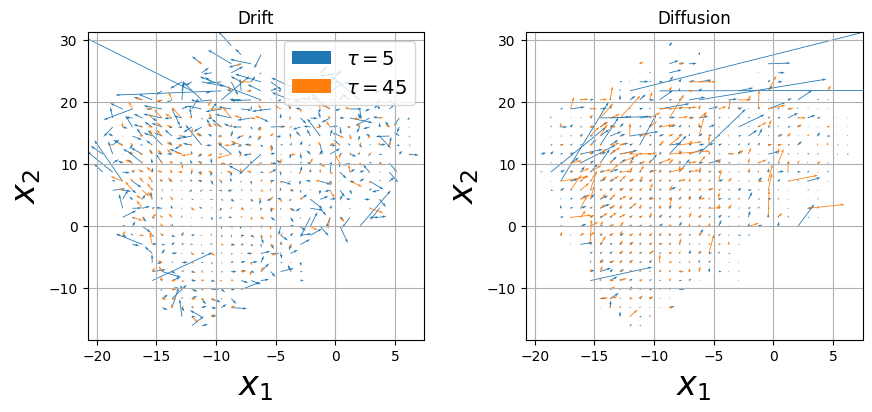

In [19]:
x1,x2 = np.meshgrid(centers0,centers1)
plt.figure(figsize=(10, 4))
plt.subplot(121)
plt.quiver(x1,x2, f_fine[:,:,0],f_fine[:,:,1],color=colors[0], label=r'$\tau=$'+str(np.round(dt,2)),scale=5)
plt.quiver(x1,x2, f_coarse[:,:,0],f_coarse[:,:,1],color=colors[1], label=r'$\tau=$'+str(np.round(dt*stride_coarse,2)),scale=5)
plt.legend(fontsize=14)
plt.title('Drift')
plt.xlabel('$x_1$', fontsize = 24)
plt.ylabel('$x_2$', fontsize = 24)
plt.grid()

plt.subplot(122)
plt.quiver(x1,x2, a_fine[:,:,0],a_fine[:,:,1],color=colors[0])
plt.quiver(x1,x2, a_coarse[:,:,0], a_coarse[:,:,1], color=colors[1])
plt.title('Diffusion')
plt.xlabel('$x_1$', fontsize = 24)
plt.ylabel('$x_2$', fontsize = 24)
plt.grid()

plt.subplots_adjust(wspace=0.3)
plt.show()

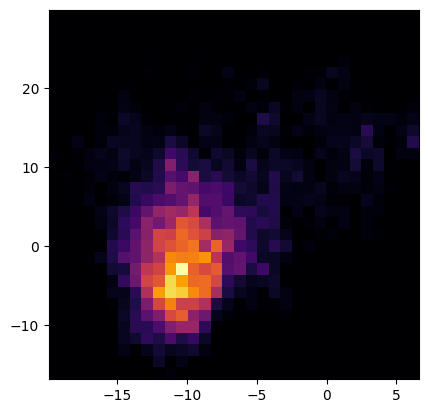

In [20]:
# PDF of states
p_hist, _, _ = np.histogram2d(np.concatenate(data_stationary)[:,0],np.concatenate(data_stationary)[:,1], bins, density=True)
plt.imshow(p_hist,interpolation='nearest', origin='lower',
           extent=[bins[0][0], bins[0][-1], bins[1][0], bins[1][-1]],
           cmap='inferno', aspect=(bins[0][-1]-bins[0][0])/(bins[1][-1]-bins[1][0]))

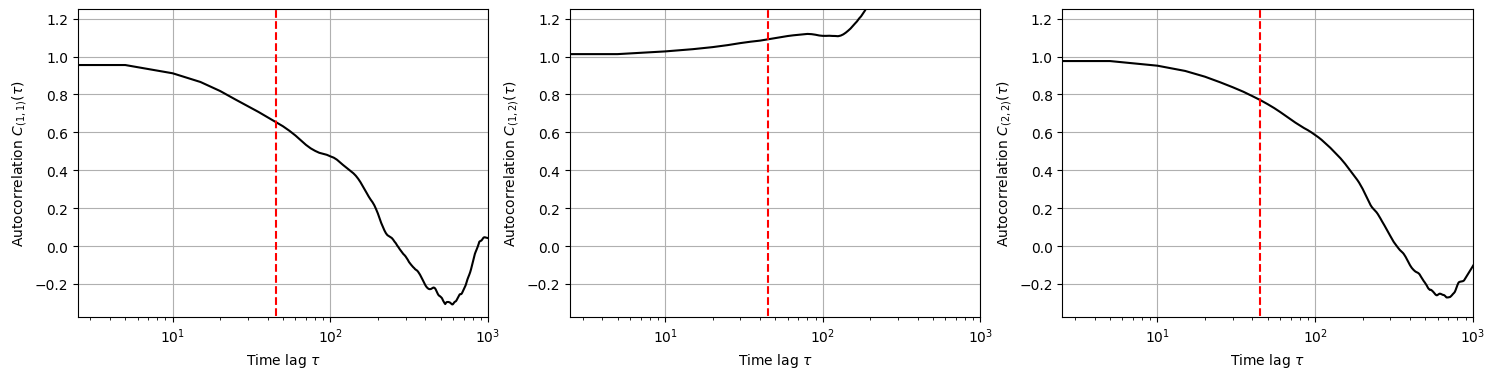

In [21]:
tau = dt*np.arange(0, data[0].shape[0])
acf = np.zeros((len(tau),2,2))
for loc_idx in range(num_loc):
    acf = acf + autocorr_func_2D(data[loc_idx])
acf = acf/num_loc


fig, axs = plt.subplots(1,3, figsize=(18, 4))
tup_list = [(0,0),(0,1),(1,1)]
for ii in range(3):
    i,j = tup_list[ii]
    axs[ii].plot(tau, acf[:,i,j], 'k')
    axs[ii].set_ylabel(r'Autocorrelation $C_{('+str(i+1)+','+str(j+1)+')}(\\tau)$')
    axs[ii].set_xlabel(r'Time lag $\tau$')
    axs[ii].vlines(stride_coarse*dt, acf.min()-0.1, acf.max()+0.1, 'r', '--')
    axs[ii].set_ylim([acf.min()-0.05, 1.25])
    axs[ii].set_xlim([0.5*dt, 1e3])
    axs[ii].set_xscale('log')
    axs[ii].grid()

/home/erin.angelini/my-envs/hcs-env/lib/python3.11/site-packages/numpy/lib/histograms.py:1067: RuntimeWarning: invalid value encountered in divide
  hist /= s
/home/erin.angelini/my-envs/hcs-env/lib/python3.11/site-packages/numpy/lib/histograms.py:885: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges
/tmp/ipykernel_15242/1090687825.py:6: RuntimeWarning: Mean of empty slice
  kl_div = np.nanmean(kl_div,axis=0)


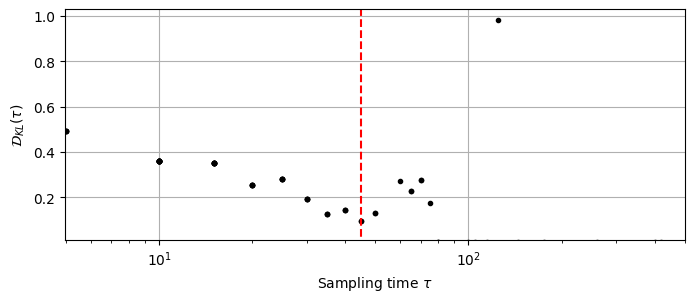

In [22]:
# Markov test
lag = np.round( np.logspace(0.1, 2, 100) ).astype(int)
kl_div = np.zeros((num_loc,len(lag)))
for loc_idx in range(num_loc):
    kl_div[loc_idx,:] = np.array([utils.markov_test(data[loc_idx][:,0], delta, N=N) for delta in lag])
kl_div = np.nanmean(kl_div,axis=0)

plt.figure(figsize=(8, 3))
plt.gca().set_xscale('log')
plt.plot(dt*lag, kl_div, 'k.')
plt.vlines(dt*stride_coarse, -0.3, 1.2, 'r', '--')

plt.ylabel(r'$\mathcal{D}_{KL}(\tau)$')
plt.xlabel(r'Sampling time $\tau$')
plt.xlim([dt*lag.min()-0.05, dt*lag.max()+0.05])
plt.ylim([1e-2, np.max([np.nanmax(kl_div)+0.05,1])])
plt.grid()

In [23]:
## Kramers-Moyal average
stride = stride_coarse  # How many snapshots to skip
f_KM, a_KM, f_err, a_err = KM_avg_2D(data, bins, stride=stride, dt=dt, multi_traj=True)

# Convert numpy arrays to torch tensors
f_KM = torch.from_numpy(f_KM)
a_KM = torch.from_numpy(a_KM)
f_err = torch.from_numpy(f_err)
a_err = torch.from_numpy(a_err)

In [36]:
### Build SINDy libraries with sympy
x1 = sympy.symbols('x1')
x2 = sympy.symbols('x2')

f_expr = np.array([(x1**i)*(x2**j) for i in np.arange(4) for j in np.arange(4)])  # Polynomial library for drift
s_expr = np.array([(x1**i)*(x2**j) for i in np.arange(3) for j in np.arange(3)])  # Polynomial library for diffusion

# Convert sympy expressions into library matrices
lib_f = np.zeros([len(f_expr),N,N])
for k in range(len(f_expr)):
    lamb_expr = sympy.lambdify([x1,x2], f_expr[k])
    lib_f[k] = lamb_expr(centers0,centers1)

lib_f = lib_f.T

lib_s = np.zeros([len(s_expr),N,N])
for k in range(len(s_expr)):
    lamb_expr = sympy.lambdify([x1,x2], s_expr[k])
    lib_s[k] = lamb_expr(centers0,centers1)

lib_s = lib_s.T

# Convert numpy arrays to torch tensors
lib_f = torch.from_numpy(lib_f)
lib_s = torch.from_numpy(lib_s)

In [50]:
# Initialize Xi with least squares regression (no finite-time corrections)

m=len(f_expr)+len(s_expr)
Xi0 = torch.zeros((m,2),dtype=torch.double)
mask = torch.where(torch.isfinite(f_KM[:,:,0])*torch.isfinite(f_KM[:,:,1]))
Xi0[:len(f_expr)] = torch.linalg.lstsq( lib_f[mask[0],mask[1]], f_KM[mask[0],mask[1]], rcond=None)[0]   # Regression against drift f1
Xi0[len(f_expr):] = torch.linalg.lstsq( lib_s[mask[0],mask[1]], np.sqrt(2*a_KM[mask[0],mask[1]]), rcond=None)[0]  # Regression against diffusion a1


In [51]:
### Weights: uncertainties in Kramers-Moyal
# This is helpful, but not that critical.  The specific choice of weights doesn't matter that much
W = np.array((f_err.flatten(), a_err.flatten()))
W[np.less(abs(W), 1e-12, where=np.isfinite(W))] = 1e6  # Set zero entries to large weights
W[np.logical_not(np.isfinite(W))] = 1e6                 # Set NaN entries to large numbers (small weights)
W = 1/W  # Invert error for weights
W = W/np.nansum(W.flatten())
W = torch.from_numpy(W)

# Compute empirical PDF
p_hist, _, _ = np.histogram2d(np.concatenate(data_stationary)[:,0],np.concatenate(data_stationary)[:,1], bins, density=True)
p_hist = torch.from_numpy(p_hist)

# Initialize adjoint solver
centers = np.vstack([centers0,centers1])
centers = torch.from_numpy(centers)

afp = lgt.AdjFP(centers,ndim=2)

# Initialize forward steady-state solver
fp = lgt.SteadyFP((N,N), dx)



# Optimization parameters
params = {"W": W, "f_KM": f_KM, "a_KM": a_KM, "Xi0": Xi0,
          "f_expr": f_expr, "s_expr": s_expr,
          "lib_f": lib_f, "lib_s": lib_s, "N": (N,N),
          "kl_reg": 10,
          "fp": fp, "afp": afp, "p_hist": p_hist, "tau": stride*dt,
          "radial": False}

# Use anonymous function to automatically pass the cost function
opt_fun = lambda params: lgt.AFP_opt(lgt.cost2, params)

In [87]:
X,V = lgt.SSR_loop(opt_fun, params)

%%%% Computing AdjFP operator time: 0.12591266632080078 seconds %%%%
%%%% Solving AdjFP time: 10.200528860092163 seconds %%%%


AttributeError: 'tuple' object has no attribute 'numpy'

In [94]:
W.shape

torch.Size([2, 2048])

In [93]:
mask = np.where(np.isfinite(f_KM.numpy()))
W[0,mask].shape

torch.Size([3, 774])

In [74]:
x = centers[0]
y = centers[1]

hx, hy = x[1]-x[0], y[1]-y[0]
Nx, Ny = len(x), len(y)

# build first derivative finite difference matrix in y (central with fwd/back at boundaries)
diag2 = torch.zeros(Ny)
diag2[2] = -1

diag1 = torch.ones(Ny)
diag1[1] = 4

diag0 = torch.zeros(Ny)
diag0[0] = -3
diag0[-1] = 3

Dy = torch.sparse.spdiags(torch.vstack([diag2, diag1,diag0,-diag1.flip(0),-diag2.flip(0)]), torch.tensor([2,1,0,-1,-2]), shape=(Ny, Ny))
# Repeat for each x-location
Dy = torch.block_diag(*Dy.to_dense()[None,:,:].repeat(Nx,1,1))/(2*hy)
Dy = Dy.to_sparse_csr()

Dx = torch.sparse.spdiags(torch.vstack([-torch.ones(Nx*Ny), torch.ones(Nx*Ny)]), torch.tensor([-Ny, Ny]), shape=(Nx*Ny, Nx*Ny)).to_dense()
# Second-order forwards/backwards at boundaries
for i in range(Ny):
    Dx[i, i] = -3
    Dx[i, Ny+i] = 4
    Dx[i, 2*Ny+i] = -1
    Dx[-(i+1), -(i+1)] = 3
    Dx[-(i+1), -(Ny+i+1)] = -4
    Dx[-(i+1), -(2*Ny+i+1)] = 1
Dx = Dx/(2*hx)
Dx = Dx.to_sparse_csr()

Dxx = Dx @ Dx
Dyy = Dy @ Dy

In [ ]:
f_vals = (lib_f @ Xi0[:lib_f.shape[-1]]).T
a_vals = (0.5*(lib_s @ Xi0[lib_f.shape[-1]:])**2).T

In [76]:
f = f_vals.reshape((2,N*N))
a = a_vals.reshape((2,N*N))

In [80]:
Dx

tensor(crow_indices=tensor([   0,    3,    6,  ..., 2106, 2109, 2112]),
       col_indices=tensor([   0,   32,   64,  ...,  959,  991, 1023]),
       values=tensor([-1.8113,  2.4151, -0.6038,  ...,  0.6038, -2.4151,
                       1.8113]), size=(1024, 1024), nnz=2112,
       layout=torch.sparse_csr)

In [81]:
torch.sparse.spdiags(f[0],torch.tensor([0]),(Nx**2,Nx**2)).to_sparse_csr()

tensor(crow_indices=tensor([   0,    1,    2,  ..., 1022, 1023, 1024]),
       col_indices=tensor([   0,    1,    2,  ..., 1021, 1022, 1023]),
       values=tensor([-0.5687, -0.2349, -0.0440,  ..., -0.5049, -0.9494,
                      -1.6389]), size=(1024, 1024), nnz=1024,
       dtype=torch.float64, layout=torch.sparse_csr)

In [83]:
torch.sparse.spdiags(f[0],torch.tensor([0]),(Nx**2,Nx**2)).to_sparse_csr().float() @ Dx

tensor(crow_indices=tensor([   0,    3,    6,  ..., 2106, 2109, 2112]),
       col_indices=tensor([   0,   32,   64,  ...,  959,  991, 1023]),
       values=tensor([ 1.0301, -1.3735,  0.3434,  ..., -0.9895,  3.9581,
                      -2.9686]), size=(1024, 1024), nnz=2112,
       layout=torch.sparse_csr)

In [84]:
L = torch.sparse.spdiags(f[0],torch.tensor([0]),(Nx**2,Nx**2)).to_sparse_csr().float() @ Dx  + \
              torch.sparse.spdiags(f[1],torch.tensor([0]),(Ny**2,Ny**2)).to_sparse_csr().float() @ Dy + \
                 torch.sparse.spdiags(a[0],torch.tensor([0]),(Nx**2,Nx**2)).to_sparse_csr().float() @ Dxx + \
                    torch.sparse.spdiags(a[1],torch.tensor([0]),(Ny**2,Ny**2)).to_sparse_csr().float() @ Dyy

In [63]:
Dy = sc.sparse.diags( [-1, 1], [-1, 1], shape=(Ny, Ny) ).toarray()
        
# Second-order forward/backwards at boundaries
Dy[0, :3] = np.array([-3, 4, -1])
Dy[-1, -3:] = np.array([1, -4, 3])
# Repeat for each x-location
Dy = sc.linalg.block_diag(*Dy.reshape(1, Ny, Ny).repeat(Nx,axis=0))/(2*hy.numpy())
Dy = sc.sparse.csr_matrix(Dy)

Dx = sc.sparse.diags( [-1, 1], [-Ny, Ny], shape=(Nx*Ny, Nx*Ny)).toarray()
# Second-order forwards/backwards at boundaries
for i in range(Ny):
    Dx[i, i] = -3
    Dx[i, Ny+i] = 4
    Dx[i, 2*Ny+i] = -1
    Dx[-(i+1), -(i+1)] = 3
    Dx[-(i+1), -(Ny+i+1)] = -4
    Dx[-(i+1), -(2*Ny+i+1)] = 1
Dx = sc.sparse.csr_matrix(Dx)/(2*hx.numpy())

Dxx = sc.sparse.csr_matrix(Dx @ Dx)
Dyy = sc.sparse.csr_matrix(Dy @ Dy)

In [69]:
sc.sparse.diags(f[0])

<1024x1024 sparse matrix of type '<class 'numpy.float64'>'
	with 1024 stored elements (1 diagonals) in DIAgonal format>

In [67]:
self.L = sparse.diags(f[0]) @ self.Dx  + sparse.diags(f[1]) @ self.Dy + \
                 sparse.diags(a[0]) @ self.Dxx + sparse.diags(a[1]) @ self.Dyy

tensor([[[-0.5687, -0.2349, -0.0440,  ..., -0.5049, -0.9494, -1.6389],
         [-0.5687, -0.2349, -0.0440,  ..., -0.5049, -0.9494, -1.6389],
         [-0.5687, -0.2349, -0.0440,  ..., -0.5049, -0.9494, -1.6389],
         ...,
         [-0.5687, -0.2349, -0.0440,  ..., -0.5049, -0.9494, -1.6389],
         [-0.5687, -0.2349, -0.0440,  ..., -0.5049, -0.9494, -1.6389],
         [-0.5687, -0.2349, -0.0440,  ..., -0.5049, -0.9494, -1.6389]],

        [[ 0.2845,  0.1358,  0.0481,  ...,  0.2333,  0.4400,  0.7595],
         [ 0.2845,  0.1358,  0.0481,  ...,  0.2333,  0.4400,  0.7595],
         [ 0.2845,  0.1358,  0.0481,  ...,  0.2333,  0.4400,  0.7595],
         ...,
         [ 0.2845,  0.1358,  0.0481,  ...,  0.2333,  0.4400,  0.7595],
         [ 0.2845,  0.1358,  0.0481,  ...,  0.2333,  0.4400,  0.7595],
         [ 0.2845,  0.1358,  0.0481,  ...,  0.2333,  0.4400,  0.7595]]],
       dtype=torch.float64)

In [ ]:
# Repeat for each x-location
Dy = torch.block_diag(*Dy.to_dense().[None,:,:].repeat(Nx,1,1))/(2*hy)
Dy = torch.sparse_csr_tensor(Dy)

Dx = torch.sparse.spdiags(torch.vstack([-torch.ones(Nx*Ny), torch.ones(Nx*Ny)]), torch.tensor([-Ny, Ny]), shape=(Nx*Ny, Nx*Ny)).to_dense()
# Second-order forwards/backwards at boundaries
for i in range(Ny):
    Dx[i, i] = -3
    Dx[i, Ny+i] = 4
    Dx[i, 2*Ny+i] = -1
    Dx[-(i+1), -(i+1)] = 3
    Dx[-(i+1), -(Ny+i+1)] = -4
    Dx[-(i+1), -(2*Ny+i+1)] = 1
Dx = torch.sparse_csr_tensor(Dx)/(2*hx)

Dxx = torch.sparse_csr_tensor(Dx @ Dx)
Dyy = torch.sparse_csr_tensor(Dy @ Dy)

torch.Size([1024, 1024])

In [ ]:
Dy = torch.block_diag(*Dy.to_dense().reshape(1, Ny, Ny).repeat(Nx,1,1))/(2*hy)


RuntimeError: shape '[1, 32, 32]' is invalid for input of size 1048576

In [ ]:
test

tensor([-2.,  1.,  1.,  1.,  1.])

In [ ]:
Nx = N
Ny = N
Dx = torch.sparse.spdiags(torch.vstack([-torch.ones(Nx*Ny), torch.ones(Nx*Ny)]), torch.tensor([-Ny, Ny]), shape=(Nx*Ny, Nx*Ny))


In [ ]:
Dx = Dx.to_sparse_coo()

In [ ]:
Dx[0,:3] = torch.tensor([-3, 4, -1])

TypeError: Cannot assign to a sparse tensor

In [ ]:
t_vec = np.arange(num_t)
u = (20-6)*(1-np.heaviside(t_vec-num_t//2,1/2)) + 6
a = 0.25
u_soft = (20-6)*(1-1/(1+np.exp(-a*(t_vec-num_t//2)))) + 6

In [ ]:
plt.plot(5*t_vec/60,u,'k-')
plt.plot(5*t_vec/60,u_soft,'b--')
plt.xlabel("Time (hours)",fontsize=16)
plt.ylabel("Flow rate (dyn/$\\text{cm}^2$)",fontsize=16)
plt.ylim([0,21])

In [ ]:
fig, ax1 = plt.subplots()

ax1.set_xlabel('time (hours)')
ax1.set_ylabel('PC1', color='black')
for i in range(num_loc):
    ax1.plot(np.arange(num_t), X_t[i,:,0], 'k-',alpha=0.1)
ax1.tick_params(axis='y', labelcolor='black')

ax2 = ax1.twinx()  # instantiate a second Axes that shares the same x-axis

ax2.set_ylabel('Flow rate $\\text{dyn}/\\text{cm}^2$', color='blue')  # we already handled the x-label with ax1
ax2.plot(np.arange(num_t), u_soft,'b--')
ax2.tick_params(axis='y', labelcolor='blue')

fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.show()